In [19]:
import yfinance as yf
from datetime import datetime, timedelta

# Calculate date range for the past month
end_date = datetime.now()
start_date = end_date - timedelta(days=30)

# Get Apple stock data
tickers = ["AAPL", "GOOG", "AMZN", "ELF", "XOM"]
aapl = yf.download(tickers, period="1y", auto_adjust=False, interval='1d')
aapl.head()

[*********************100%***********************]  5 of 5 completed


Price        Adj Close                                                  \
Ticker            AAPL        AMZN         ELF        GOOG         XOM   
Date                                                                     
2024-05-22  190.011368  183.130005  155.630005  177.160873  111.588974   
2024-05-23  186.010086  181.050003  184.770004  174.234741  109.685356   
2024-05-24  189.095657  180.750000  191.419998  175.498779  109.598381   
2024-05-28  189.105606  182.149994  193.240005  177.180801  110.989861   
2024-05-29  189.404221  182.020004  183.770004  176.563705  109.801308   

Price            Close                                                  ...  \
Ticker            AAPL        AMZN         ELF        GOOG         XOM  ...   
Date                                                                    ...   
2024-05-22  190.899994  183.130005  155.630005  178.000000  115.480003  ...   
2024-05-23  186.880005  181.050003  184.770004  175.059998  113.510002  ...   
2024-05-24  189.979996  180.750000  191.419998  176.330002  113.419998  ...   
2024-05-28  189.990005  182.149994  193.240005  178.020004  114.860001  ...   
2024-05-29  190.289993  182.020004  183.770004  177.399994  113.629997  ...   

Price             Open                                                  \
Ticker            AAPL        AMZN         ELF        GOOG         XOM   
Date                                                                     
2024-05-22  192.270004  183.880005  157.679993  178.399994  117.459999   
2024-05-23  190.979996  183.660004  172.789993  178.779999  115.599998   
2024-05-24  188.820007  181.649994  185.509995  176.520004  114.839996   
2024-05-28  191.509995  179.929993  192.800003  175.740005  113.519997   
2024-05-29  189.610001  181.699997  191.389999  176.809998  114.529999   

Price         Volume                                         
Ticker          AAPL      AMZN      ELF      GOOG       XOM  
Date                                                         
2024-05-22  34648500  28148800  2871800  16189400  17879300  
2024-05-23  51005900  33670200  7666900  14928400  15979800  
2024-05-24  36294600  27434100  2548100  11400600  12211400  
2024-05-28  52280100  29927000  1481300  15655300  13978300  
2024-05-29  53068000  32009300  1143500  15023800  13902000  

[5 rows x 30 columns]

In [20]:

prices = aapl["Adj Close"]  # select the adjusted close columns
prices = prices.dropna()    # drop days where any stock’s price is missing
print(prices.head())
daily_returns = prices.pct_change().dropna()
daily_returns.count()

Ticker            AAPL        AMZN         ELF        GOOG         XOM
Date                                                                  
2024-05-22  190.011368  183.130005  155.630005  177.160873  111.588974
2024-05-23  186.010086  181.050003  184.770004  174.234741  109.685356
2024-05-24  189.095657  180.750000  191.419998  175.498779  109.598381
2024-05-28  189.105606  182.149994  193.240005  177.180801  110.989861
2024-05-29  189.404221  182.020004  183.770004  176.563705  109.801308


Ticker
AAPL    249
AMZN    249
ELF     249
GOOG    249
XOM     249
dtype: int64

In [21]:
# Compute sample mean and covariance from historical returns
mu_daily = daily_returns.mean()
Sigma = daily_returns.cov()

# Convert daily mean to annual (multiply by 252 trading days)
mu_annual = mu_daily * 252
print("Expected annual returns:", mu_annual)
print("Covariance matrix:\n", Sigma * 252)

Expected annual returns: Ticker
AAPL    0.116327
AMZN    0.154722
ELF    -0.433248
GOOG    0.007431
XOM    -0.045674
dtype: float64
Covariance matrix:
 Ticker      AAPL      AMZN       ELF      GOOG       XOM
Ticker                                                  
AAPL    0.109598  0.067092  0.069035  0.053984  0.027622
AMZN    0.067092  0.120508  0.075669  0.070352  0.017160
ELF     0.069035  0.075669  0.496881  0.054861  0.019770
GOOG    0.053984  0.070352  0.054861  0.097860  0.012433
XOM     0.027622  0.017160  0.019770  0.012433  0.057639


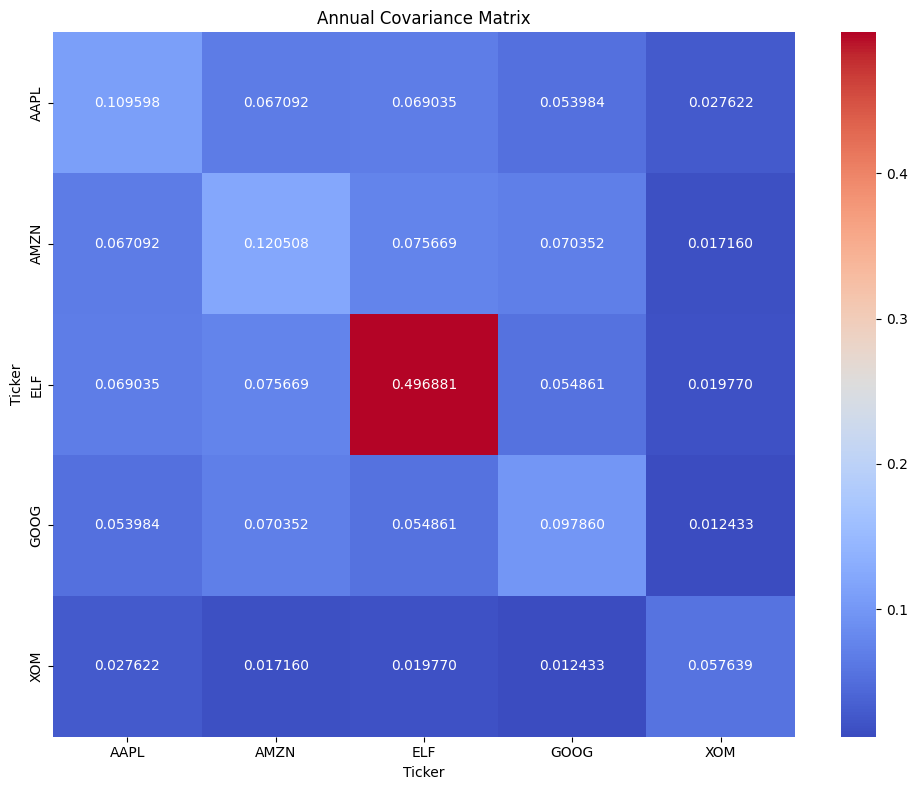

In [22]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create a heatmap of the covariance matrix
plt.figure(figsize=(10, 8))
sns.heatmap(Sigma * 252, annot=True, cmap='coolwarm', fmt='.6f', 
            xticklabels=Sigma.index, yticklabels=Sigma.index)
plt.title('Annual Covariance Matrix')
plt.tight_layout()
plt.show()